# Прогнозирование и калибровка CTR для рекламной платформы Advandex

Автор: Якунин Михаил

Дата: 24 мая 2026 г.

***По этой ссылке можно посмотреть исходный код проекта и скачать последнюю версию: https://github.com/MEYakunin/Sprint12_CTR_prediction.git***

## Цель проекта

Построить бинарный классификатор (SVM и логистическая регрессия) для предсказания вероятности клика по рекламному объявлению и выполнить калибровку предсказаний, чтобы обеспечить соответствие между предсказанными вероятностями и реальной частотой кликов.

## Задача проекта

* Обработать и проанализировать анонимизированные данные о показах рекламы.
* Отобрать наиболее информативные признаки с помощью фильтрационных методов и методов-обёрток.
* Обучить SVM с линейным ядром и логистическую регрессию.
* Настроить гиперпараметры через GridSearchCV.
* Провести калибровку вероятностей (изотоническая регрессия).
* Оценить модели по PR-AUC, Log Loss, Brier Score, ECE/MCE.

## Содержание <a id=content></a>

1. [Подготовка среды и загрузка данных](#1)
2. [Исследовательский анализ данных (EDA)](#2)
3. [Разделение данных на выборки](#3)
4. [Предобработка данных — построение пайплайнов](#4)
5. [Отбор признаков](#5)
6. [Обучение базовой модели](#6)
7. [Подбор гиперпараметров: Grid Search с кросс-валидацией](#7)
8. [Финальная модель](#8)
9. [Калибровка модели](#9)
10. [Калибровка модели](#10)
11. [Финальный отчёт и выводы](#11)
12. [Сохранение модели для продакшена](#12)

## [Этап 1. Подготовка среды и загрузка данных <a id=1></a>](#content)

**В этом этапе мы:**
- импортируем библиотеки и настроим параметры отображения графиков и датафреймов;
- зафиксируем значение `RANDOM_SEED` для воспроизводимости результатов;
- загрузим исходные данные из CSV-файла;
- выполним первичный просмотр данных: размер, первые строки, типы столбцов, общая статистика.

In [1]:
# Устанавливаем все необходимые библиотеки
#!pip install requirements.txt

In [44]:
# Загружаем библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from category_encoders import TargetEncoder


In [3]:
# Настраиваем параметры отображения графиков и датафреймов
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [4]:
# Фиксируем константные значения
random_state = 11

In [5]:
# Загружаем датасет
df = pd.read_csv('datasets/ds_s16_ad_click_dataset.csv', sep=',', decimal='.')

In [6]:
# Выводим общую информацию о датафрейме
display(df.head(5))
df.info()
df.describe(include='all').T

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,50000.0,NaN,NaN,NaN,9215402302107276288.0,5328516395922775040.0,31910769195310.0,4580648973216844800.0,9243014535888650240.0,13809198391134916608.0,18446516750890600448.0
click,50000.0,NaN,NaN,NaN,0.17206,0.377436,0.0,0.0,0.0,0.0,1.0
hour,50000.0,NaN,NaN,NaN,14102559.0435,296.789151,14102100.0,14102304.0,14102602.0,14102814.0,14103023.0
C1,50000.0,NaN,NaN,NaN,1004.97006,1.110202,1001.0,1005.0,1005.0,1005.0,1012.0
banner_pos,50000.0,NaN,NaN,NaN,0.29138,0.514201,0.0,0.0,0.0,1.0,7.0
site_id,50000,1160,85f751fd,18011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_domain,50000,1013,c4e18dd6,18645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_category,50000,18,50e219e0,20457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_id,50000,976,ecad2386,31989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_domain,50000,67,7801e8d9,33763,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Промежуточный итог по этапу 1:

1. Библиотеки успешно импортированы, заданы настройки отображения (`display.max_columns`, `plt.style.use`).
2. Зафиксирован `random_state = 11` — это обеспечит воспроизводимость при случайных разделениях и инициализациях моделей.
3. Данные загружены из файла `'/datasets/ds_s16_ad_click_dataset.csv'`.
4. Размер датасета: **50 000 строк, 34 столбца**.
5. Типы данных:
   - **числовые** (`int64`, `float64`) – 23 столбца;
   - **категориальные** (`object` / `str`) – 11 столбцов.
6. Пропусков в данных нет (Non-Null Count для всех столбцов равен 50 000).
7. Целевая переменная `click` имеет два значения (0/1), её распределение будет подробно исследовано на этапе EDA.

Все подготовительные действия выполнены, данные готовы к дальнейшему анализу.

## [Этап 2. Исследовательский анализ данных (EDA) <a id=2></a>](#content)

### 2.1 Анализ целевой переменной

Распределение целевой переменной "click":


,Признак,count
0,0,41397
1,1,8603


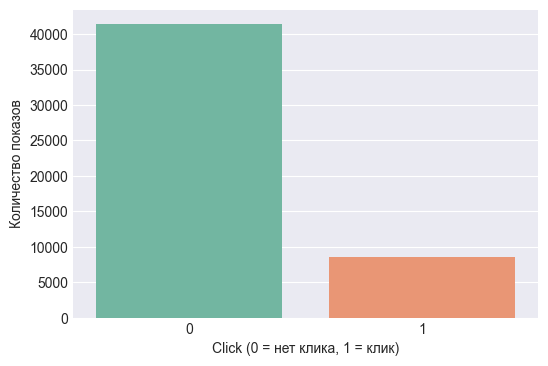

In [7]:
# Анализ распределения целевой переменной click
print('Распределение целевой переменной "click":')
display(df['click'].value_counts() \
                .reset_index() \
                .rename(columns={'click': 'Признак'}))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='click', hue='click', palette='Set2', legend=False)
plt.xlabel('Click (0 = нет клика, 1 = клик)')
plt.ylabel('Количество показов')
plt.show()

In [8]:
# Дополнительно: посчитаем долю кликов в процентах
click_rate = df['click'].mean() * 100
print(f"\nДоля кликов (CTR) в датасете: {click_rate:.2f}%")


Доля кликов (CTR) в датасете: 17.21%


**Сильный дисбаланс классов:**  
  - Класс `0` (нет клика) значительно преобладает над классом `1` (клик).  
  - Доля кликов составляет примерно около `17%`. Это типичная ситуация для задач прогнозирования `CTR`.
  - Целевая переменная сильно несбалансирована, что обосновывает выбор `PR-AUC` в качестве основной метрики и требует стратифицированного разделения выборок.

### 2.2 Анализ пропущенных значений

In [9]:
# Проверка кол-во пропусков в каждом признаке
df.isnull().sum()

id                  0
click               0
hour                0
C1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
ml_feature_1        0
ml_feature_2        0
ml_feature_3        0
ml_feature_4        0
ml_feature_5        0
ml_feature_6        0
ml_feature_7        0
ml_feature_8        0
ml_feature_9        0
ml_feature_10       0
dtype: int64

Как видно из кода, **ни один из признаков не содержит пропущенных значений**. Все 33 признака (после удаления `id`, `hour`, `device_ip`) имеют полные данные. Отсутствие пропусков упрощает предобработку: не требуется применять `SimpleImputer` или удалять строки. Однако для универсальности кода и на случай появления пропусков в будущих данных (например, в продакшене) можно оставить imputer в пайплайне с настройками по умолчанию.

Если бы пропуски были, мы бы использовали:
- **Для числовых признаков:** медиана (устойчива к выбросам).
- **Для категориальных признаков:** константа `'unknown'` (сохраняет информацию о факте пропуска).

Пропуски отсутствуют, поэтому шаг заполнения пропусков можно пропустить или оставить imputer в пайплайне как запасной вариант (он не изменит данные, если пропусков нет).

### 2.3 Анализ признаков

In [10]:
# Список всех признаков
print("Все признаки в датасете:")
print(df.columns.tolist())

Все признаки в датасете:
['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_7', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


In [11]:
# Разделение по типам данных (фактические типы)
print("\nТипы данных:")
print(df.dtypes)


Типы данных:
id                  float64
click                 int64
hour                  int64
C1                    int64
banner_pos            int64
site_id                 str
site_domain             str
site_category           str
app_id                  str
app_domain              str
app_category            str
device_id               str
device_ip               str
device_model            str
device_type           int64
device_conn_type      int64
C14                   int64
C15                   int64
C16                   int64
C17                   int64
C18                   int64
C19                   int64
C20                   int64
C21                   int64
ml_feature_1        float64
ml_feature_2            str
ml_feature_3        float64
ml_feature_4          int64
ml_feature_5        float64
ml_feature_6        float64
ml_feature_7            str
ml_feature_8        float64
ml_feature_9        float64
ml_feature_10       float64
dtype: object


In [12]:
# Определяем типы признаков
numeric_by_dtype = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_by_dtype = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"\nЧисловые признаки (по dtype ['int64', 'float64']): {numeric_by_dtype}")
print(f"Категориальные признаки (по dtype ['object', 'string']): {categorical_by_dtype}")


Числовые признаки (по dtype ['int64', 'float64']): ['id', 'click', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']
Категориальные признаки (по dtype ['object', 'string']): ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'ml_feature_2', 'ml_feature_7']


In [13]:
# Важное замечание: некоторые числовые признаки на самом деле категориальные (мало уникальных значений)
# Их мы будем обрабатывать как категориальные при кодировании
potential_categorical_numeric = ['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']
print(f"\nЧисловые признаки с малым числом уникальных значений (категориальные по сути):\n{potential_categorical_numeric}")


Числовые признаки с малым числом уникальных значений (категориальные по сути):
['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']


**Типы признаков:**
- **Категориальные (object):** `site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `device_id`, `device_model`, `ml_feature_2`, `ml_feature_7`
- **Числовые (int64):** `id`, `click`, `C1`, `banner_pos`, `device_type`, `device_conn_type`, `C14`, `C15`, `C16`, `C17`, `C18`, `C19`, `C20`, `C21`, `ml_feature_1`, `ml_feature_3`, `ml_feature_4`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10`

**Важные нюансы:**
- Некоторые числовые признаки имеют **очень мало уникальных значений** (например, `C1` – 7, `banner_pos` – 7, `device_type` – 4, `device_conn_type` – 4, `C14` - 1497, `C15` – 8, `C16` – 9, `C17` - 387, `C18` – 4, `C19` - 64, `C20` - 149, `C21` - 59). По сути, они являются категориальными, но представлены числами. Их следует кодировать как категории (One-Hot Encoding), а не масштабировать.
- Признаки `ml_feature_1`, `ml_feature_3`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10` имеют 50 000 уникальных значений (почти каждая строка уникальна). Это похоже на непрерывные или высокоразмерные числовые признаки. Их нужно масштабировать.
- `click` — целевая переменная (2 значения).

**Бесполезные признаки (удаляем сразу)**
1. **`id`** – уникальный идентификатор каждой записи. Не несёт предсказательной силы.
2. **`hour`** – временная метка. В чистом виде может привести к переобучению (модель запомнит конкретные часы). Можно было бы извлечь час дня, но в рамках первой итерации удалим.
3. **`device_ip`** – слишком много уникальных значений, не обобщается. Удаляем.

In [14]:
# Удаляем бесполезные признаки
df_clean = df.drop(columns=['id', 'hour', 'device_ip'])

### 2.4 Анализ категориальных признаков

In [15]:
# Категориальные признаки: object + числовые с малым числом уникальных значений (кроме целевой)
categorical_cols = df_clean.select_dtypes(include=['object', 'string']).columns.tolist()

# Добавляем числовые, которые являются категориальными
# numeric_categorical = ['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']
all_categorical = categorical_cols #+ numeric_categorical

In [16]:
# Создадим списки для признаков с малой и высокой кардинальностью 
low_categorical = []
high_categorical = []

# Анализ количества уникальных значений для каждого категориального признака
print("\nКоличество уникальных значений в категориальных признаках:")
for col in all_categorical:
    n_unique = df_clean[col].nunique()
    print(f"  {col}: {n_unique} уникальных значений")
    if n_unique > 50:
        high_categorical.append(col)
    else:
        low_categorical.append(col)


Количество уникальных значений в категориальных признаках:
  site_id: 1160 уникальных значений
  site_domain: 1013 уникальных значений
  site_category: 18 уникальных значений
  app_id: 976 уникальных значений
  app_domain: 67 уникальных значений
  app_category: 22 уникальных значений
  device_id: 8580 уникальных значений
  device_model: 2521 уникальных значений
  ml_feature_2: 5 уникальных значений
  ml_feature_7: 3 уникальных значений


**Стратегии кодирования:**
- **One-Hot Encoding** — для признаков с числом уникальных значений ≤ 20 (или небольшое). Это: `site_category`, `app_category`, `ml_feature_2`, `ml_feature_7`, а также все числовые категориальные (`C1`, `banner_pos`, `device_type`, `device_conn_type`, `C15`, `C16`, `C18`).  
  *Обоснование:* они имеют не более 22 категорий, One-Hot не приведёт к взрывному росту признаков.
- **Target Encoding** — для признаков с высокой кардинальностью (более 50 уникальных значений): `site_id`, `site_domain`, `app_id`, `app_domain`, `device_id`, `device_model`.  
  *Обоснование:* One-Hot создал бы тысячи новых столбцов, что неэффективно. Target Encoding заменяет каждую категорию на средний CTR по ней, что компактно и информативно.
 
Определены все категориальные признаки, включая скрытые в числовых. Выбраны методы кодирования.

### 2.5 Анализ числовых признаков (распределения, выбросы)

In [17]:
# Определяем числовые признаки для масштабирования
numeric_cols = list(set(df_clean.columns) - set(all_categorical) - set(['click']))

In [18]:
# Описательные статистики числовых признаков
print("\nСтатистики для числовых признаков:")
display(df_clean[numeric_cols].describe())


Статистики для числовых признаков:


,device_type,ml_feature_3,ml_feature_4,C21,ml_feature_1,C20,ml_feature_5,C15,ml_feature_8,C1,ml_feature_9,C17,C14,C18,ml_feature_6,device_conn_type,ml_feature_10,C19,C16,banner_pos
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.018120,-0.036381,0.498040,83.685180,-0.002445,53173.383240,0.034729,318.86640,0.025465,1004.970060,0.035361,2109.781020,18826.648680,1.428100,0.022948,0.337160,0.020226,227.703800,59.692480,0.291380
std,0.538477,5.792335,0.500001,70.539513,1.000280,49960.181871,1.002116,20.56153,0.578026,1.110202,0.505034,612.963141,4983.064178,1.327413,0.656690,0.860057,0.303309,351.592108,46.720842,0.514201
min,0.000000,-9.999742,0.000000,13.000000,-4.631262,-1.000000,-4.631853,120.00000,-0.999965,1001.000000,-2.147526,112.000000,375.000000,0.000000,-1.000000,0.000000,-1.287965,33.000000,20.000000,0.000000
25%,1.000000,-5.059555,0.000000,23.000000,-0.677784,-1.000000,-0.639829,320.00000,-0.470627,1005.000000,-0.304077,1823.000000,16920.000000,0.000000,-0.579775,0.000000,-0.182386,35.000000,50.000000,0.000000
50%,1.000000,-0.056155,0.000000,61.000000,-0.003776,100049.000000,0.028112,320.00000,0.027348,1005.000000,0.035985,2323.000000,20346.000000,2.000000,0.037786,0.000000,0.018930,39.000000,50.000000,0.000000
75%,1.000000,4.985939,1.000000,108.000000,0.673534,100094.000000,0.707594,320.00000,0.521117,1005.000000,0.374152,2526.000000,21916.000000,3.000000,0.637131,0.000000,0.224080,171.000000,50.000000,1.000000
max,5.000000,9.999975,1.000000,255.000000,3.793828,100248.000000,4.230623,1024.00000,1.119858,1012.000000,2.120786,2757.000000,24043.000000,3.000000,1.000000,5.000000,1.202300,1839.000000,1024.000000,7.000000


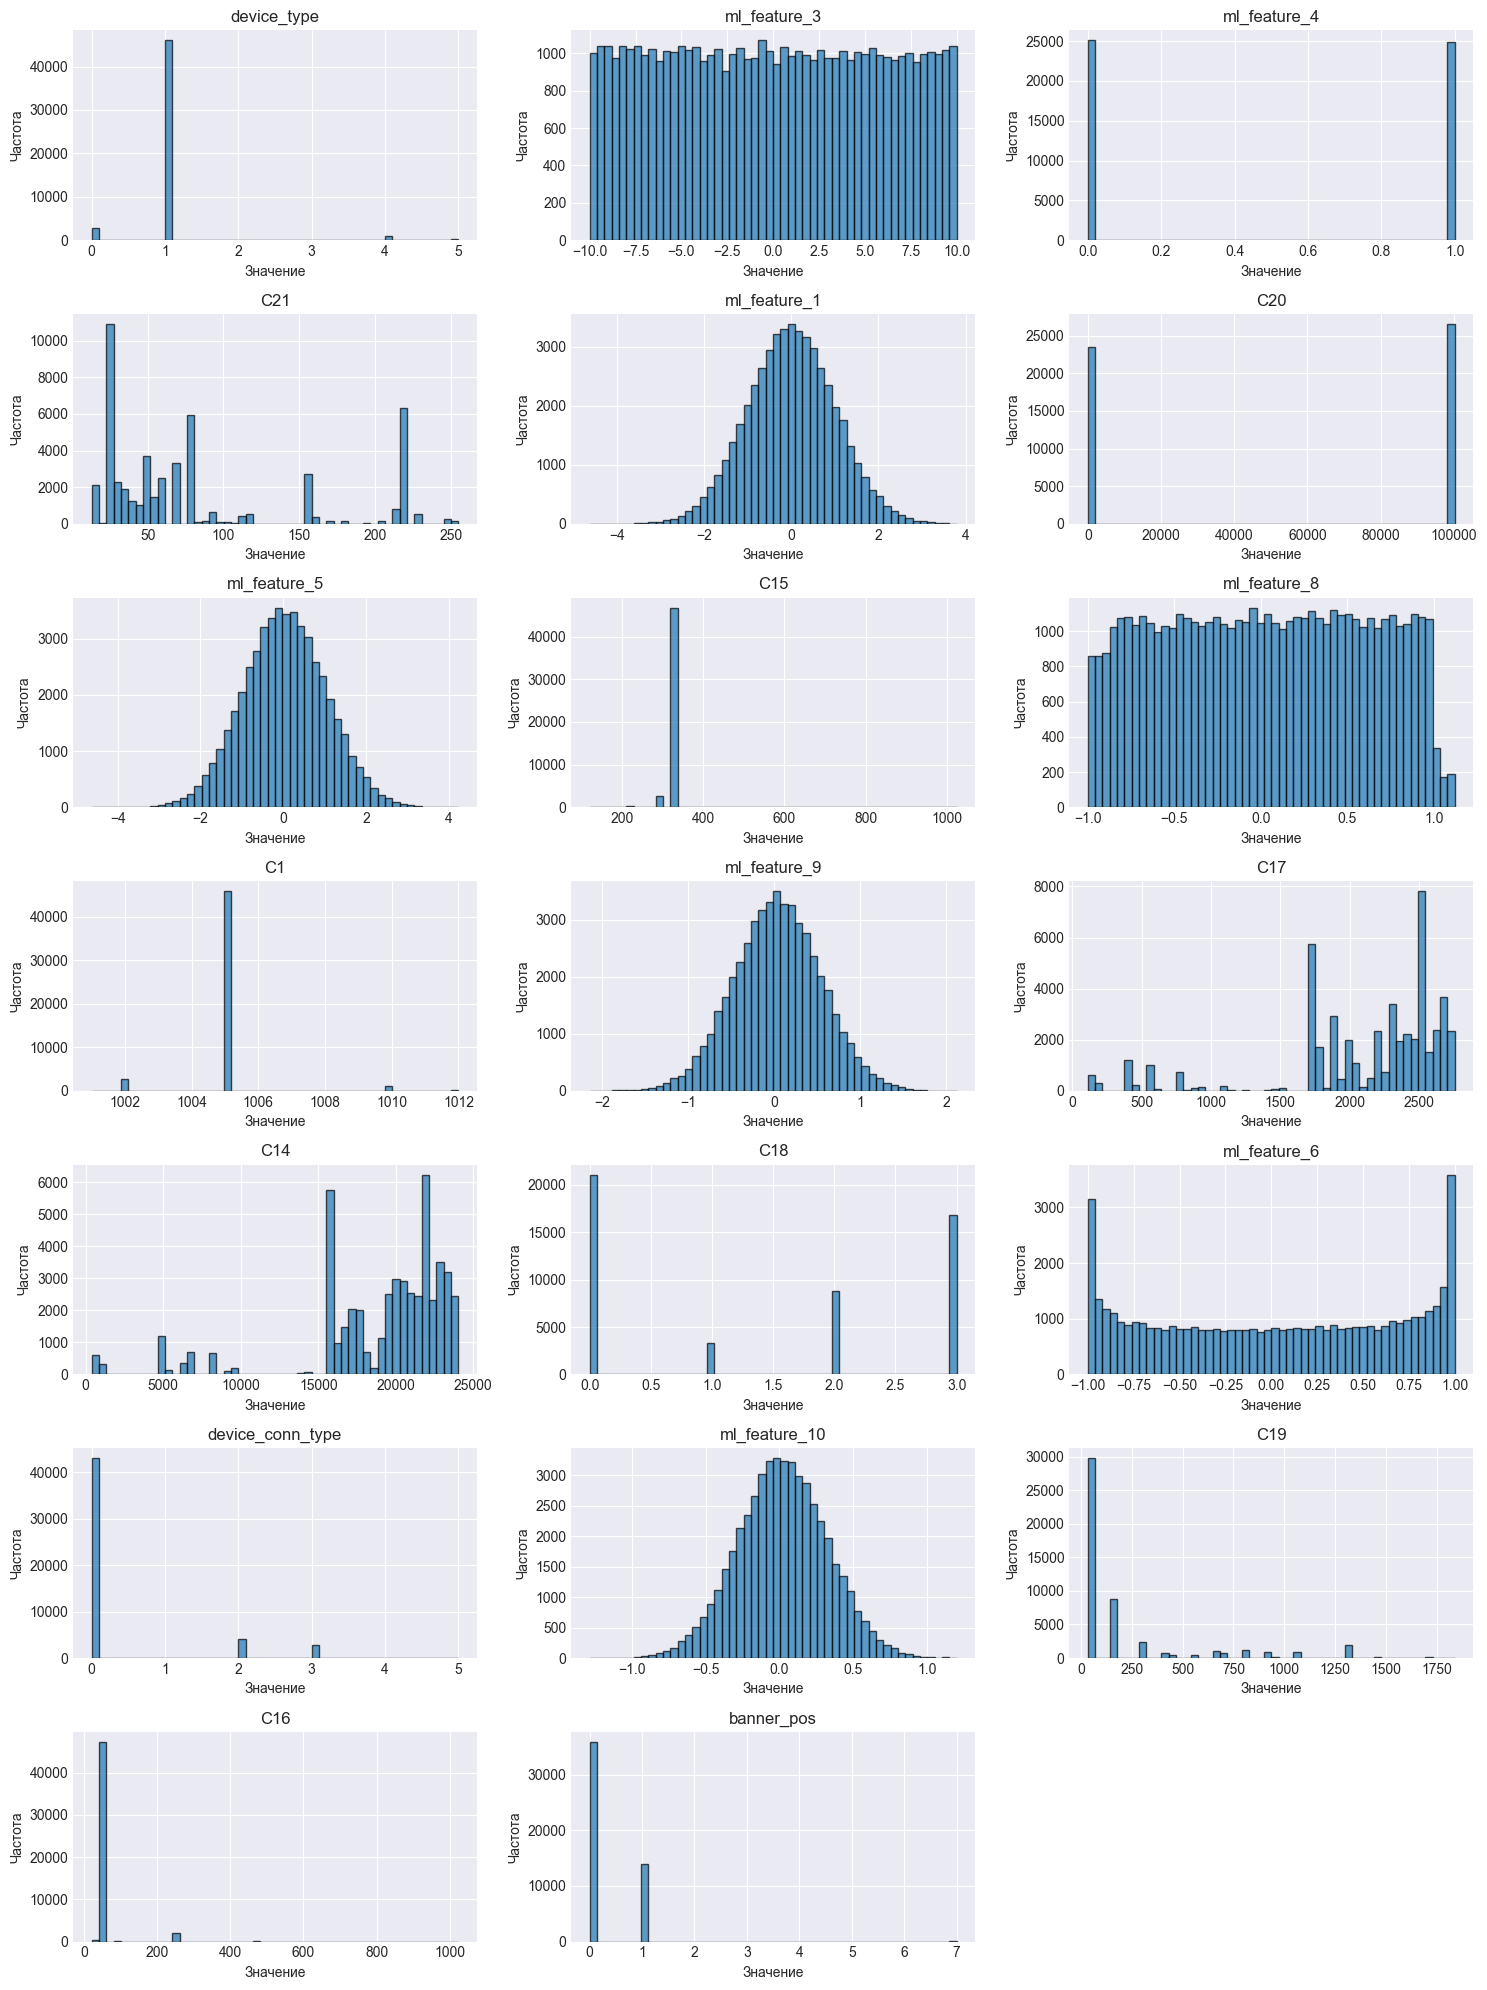

In [19]:
# Визуализация распределений (гистограммы)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=len(numeric_cols)//3 + 1, ncols=3, figsize=(15, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df[col].hist(bins=50, ax=axes[i], alpha=0.7, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [20]:
# Выбросы: используем IQR для каждого признака
print("\nАнализ выбросов (по IQR):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} выбросов ({len(outliers)/len(df)*100:.2f}%)")


Анализ выбросов (по IQR):
device_type: 3969 выбросов (7.94%)
ml_feature_3: 0 выбросов (0.00%)
ml_feature_4: 0 выбросов (0.00%)
C21: 379 выбросов (0.76%)
ml_feature_1: 347 выбросов (0.69%)
C20: 0 выбросов (0.00%)
ml_feature_5: 360 выбросов (0.72%)
C15: 3213 выбросов (6.43%)
ml_feature_8: 0 выбросов (0.00%)
C1: 4165 выбросов (8.33%)
ml_feature_9: 387 выбросов (0.77%)
C17: 4224 выбросов (8.45%)
C14: 4170 выбросов (8.34%)
C18: 0 выбросов (0.00%)
ml_feature_6: 0 выбросов (0.00%)
device_conn_type: 6979 выбросов (13.96%)
ml_feature_10: 352 выбросов (0.70%)
C19: 9015 выбросов (18.03%)
C16: 2713 выбросов (5.43%)
banner_pos: 85 выбросов (0.17%)


**Ключевые наблюдения:**
- `ml_feature_4` — бинарный признак (0 или 1), среднее ~0.5.
- `ml_feature_3` имеет самый высокий стандартный разброс (std ≈ 5.79) и диапазон от -10 до 10.
- Остальные признаки имеют std близкий к 1 или меньше, диапазоны умеренные.
- Почти все признаки имеют 50 000 уникальных значений (кроме `ml_feature_4`), что говорит о высокой информативности и непрерывном характере.

**Вывод по выбросам:**
- В четырёх признаках (`ml_feature_1`, `ml_feature_5`, `ml_feature_9`, `ml_feature_10`) присутствуют выбросы на уровне ~0.7% от всех данных. Это небольшая доля.
- Признаки `ml_feature_3`, `ml_feature_4`, `ml_feature_6`, `ml_feature_8` не имеют выбросов по методу IQR.

**Стратегия обработки:**
1. **Масштабирование** — обязательно для всех 8 признаков. SVM чувствителен к масштабу признаков. Используем `StandardScaler`, который приводит данные к нулевому среднему и единичному стандартному отклонению. Это особенно важно для `ml_feature_3` с большим разбросом.
2. **Выбросы** — удалять не будем. Во-первых, их доля мала (менее 1%). Во-вторых, выбросы могут нести полезную информацию для модели. SVM с линейным ядром и регуляризацией (параметр C) достаточно устойчив к выбросам. Масштабирование уменьшит их влияние, но не устранит полностью. Если в дальнейшем качество модели будет низким, можно рассмотреть winsorization, но на старте оставляем как есть.
3. **Бинарный признак `ml_feature_4`** — можно масштабировать (стандартизация превратит 0/1 в числа с плавающей точкой), это не навредит, так как SVM работает с любыми числами. Альтернатива: оставить без масштабирования, но для единообразия лучше включить в `StandardScaler`.

### 2.6 Анализ корреляции

In [32]:
# Корреляция числовых признаков с целевой переменной 'click'
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

print("Корреляция Пирсона числовых признаков с целевой переменной 'click':")
corr_with_target = df[numeric_cols].corr()['click'].drop('click').sort_values(ascending=False)
print(corr_with_target)

Корреляция Пирсона числовых признаков с целевой переменной 'click':
ml_feature_9        0.145883
ml_feature_10       0.130906
C16                 0.129796
ml_feature_8        0.080062
ml_feature_6        0.071566
ml_feature_5        0.062550
banner_pos          0.025069
C18                 0.022078
ml_feature_3        0.002935
ml_feature_1        0.002054
C19                -0.000178
ml_feature_4       -0.003141
C15                -0.030018
device_type        -0.043879
C1                 -0.047655
C20                -0.048712
C17                -0.057804
C14                -0.064033
C21                -0.064706
device_conn_type   -0.081364
Name: click, dtype: float64


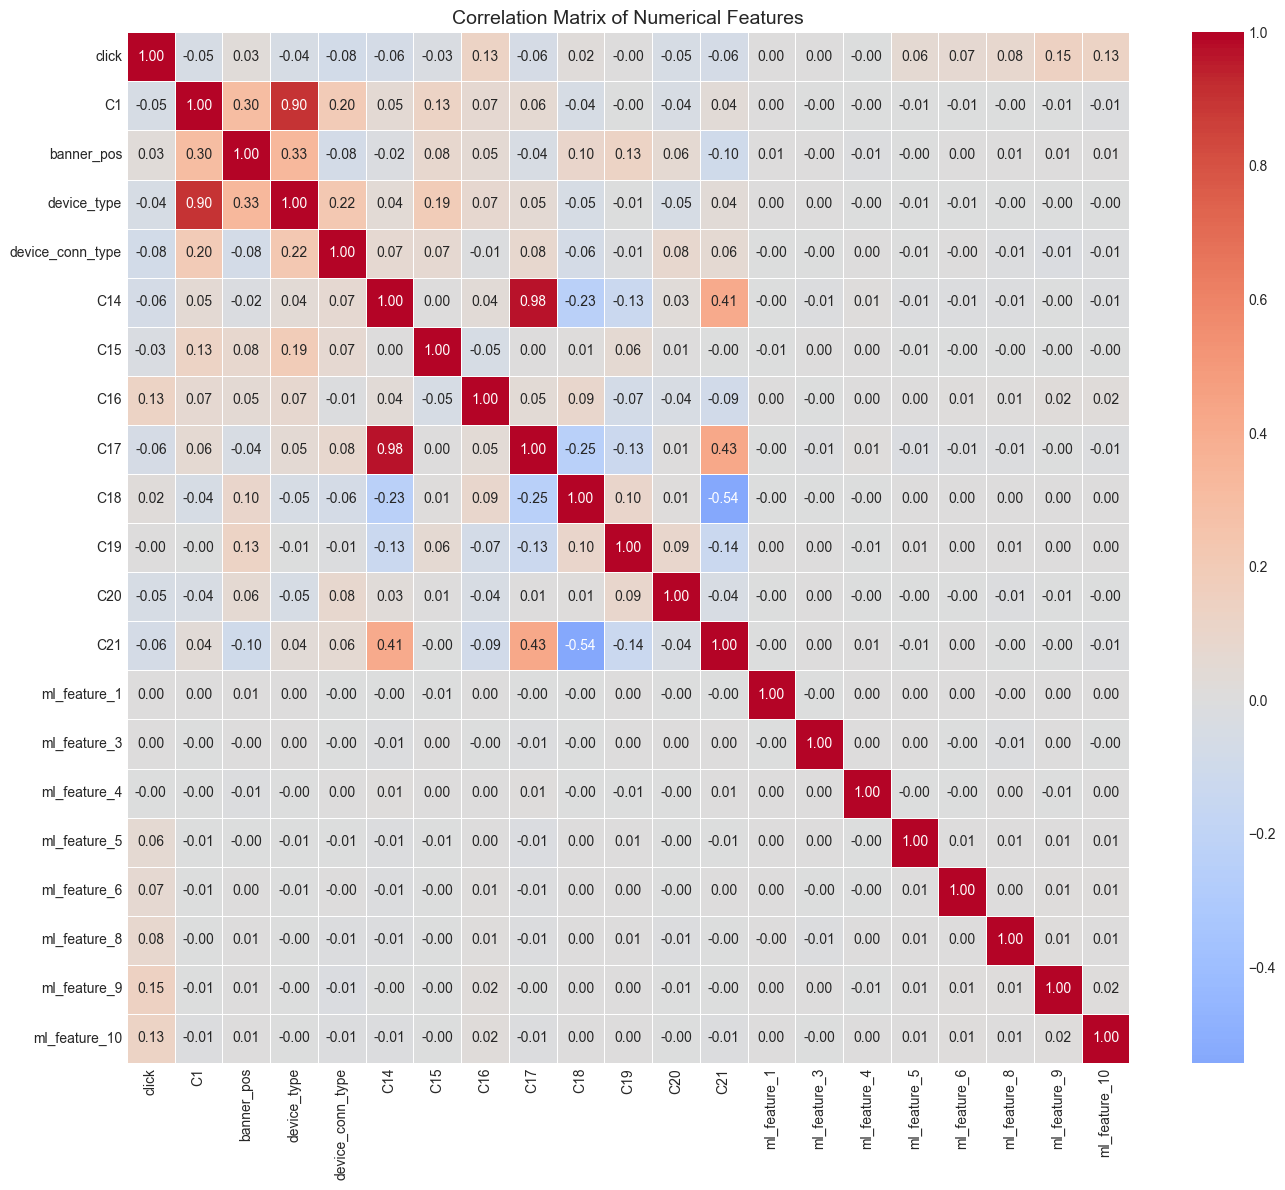

In [22]:
# Тепловая карта корреляций всех числовых признаков
plt.figure(figsize=(14, 12))
sns.heatmap(df_clean[numeric_cols].corr(), 
            annot=True,     
            fmt='.2f',      
            cmap='coolwarm', 
            center=0,
            linewidths=0.5, 
            linecolor='white')
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()  
plt.show()

**Корреляция признаков с целевой переменной `click`**

Ни один из числовых признаков не имеет сильной линейной связи с целевой переменной. Это ожидаемо для CTR-задач, где сигнал слабый и требует нелинейных методов или комбинаций признаков. Тем не менее, признаки с наибольшей корреляцией (`ml_feature_9`, `ml_feature_10`, `C16`) могут оказаться полезными.

**Корреляции между признаками (мультиколлинеарность)**

Обнаружены **очень сильные линейные связи** между некоторыми признаками:

- `C1` и `device_type` → 0.899
- `C14` и `C17` → 0.976

**Мультиколлинеарность:**  
  При использовании линейного `SVM` с регуляризацией (параметр C) проблема не критична. Однако если мы будем применять методы-обёртки (`RFE`), они могут давать разные наборы признаков при наличии коррелированных групп. Будем осторожны.

  Корреляционный анализ выявил слабую линейную связь признаков с `click`, но сильную связь между самими признаками (`C1`–`device_type`, `C14`–`C17`). Это будет учтено при отборе признаков и настройке регуляризации моделей.

### 2.7 Промежуточный итог по EDA

**Ключевые находки**

- Данные не содержат пропусков, что упрощает предобработку.
- Сильный дисбаланс классов требует осторожного выбора метрик и стратификации.
- Признаки разделены на три группы:
  - непрерывные числовые (8 ml‑features) → масштабирование;
  - категориальные с малой кардинальностью → One‑Hot;
  - категориальные с высокой кардинальностью → Target Encoding.
- Выбросы в числовых признаках немногочисленны, их решено не удалять.
- Корреляция с целевой переменной низкая, что типично для CTR‑задач; основной вклад, вероятно, дадут высокоуровневые категориальные признаки после кодирования.

**Наиболее перспективные признаки для модели**

- По корреляции с `click`: `ml_feature_9`, `ml_feature_10`, `C16`.
- Высококардинальные категориальные признаки (`site_id`, `device_id` и др.) после Target Encoding могут быть очень информативны, так как они кодируются средним CTR по категории.
- Также стоит включить все признаки, удалив только явно бесполезные (`id`, `hour`, `device_ip`).

**Действия по предобработке**

- Удалить `id`, `hour`, `device_ip` (уже сделано).
- Масштабировать 8 числовых ml‑features через `StandardScaler`.
- Применить One‑Hot Encoding для категориальных признаков с малым числом уникальных значений (список выше).
- Применить Target Encoding для высококардинальных категорий (`site_id`, `site_domain`, `app_id`, `app_domain`, `device_id`, `device_model`).
- Объединить все преобразования в единый `ColumnTransformer` внутри `Pipeline`, чтобы избежать утечки данных.

**Дополнительные замечания**

- Поскольку пропуски отсутствуют, `SimpleImputer` можно не включать, но для надёжности оставим его с параметрами по умолчанию (он не изменит данные).
- При использовании Target Encoding необходимо обучать его только на тренировочных данных (это автоматически обеспечит `Pipeline`).
- Результат: данные полностью подготовлены для построения пайплайнов, отбора признаков и последующего обучения моделей.

## [Этап 3. Разделение данных на выборки <a id=3></a>](#content)

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [23]:
# Определяем признаки и целевую переменную
X = df_clean.drop(columns= ['click'])
y = df_clean['click']

In [24]:
# Разделяем данные: 80% - обучение, 20% - тест
# Используем стратификацию для сохранения баланса классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

# Проверяем размеры выборок
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("\n")

Размер обучающей выборки: (40000, 30)
Размер тестовой выборки: (10000, 30)




In [25]:
# Проверяем распределение целевой переменной
print("\nПроверка сохранения пропорций:")
print(f"Исходная доля кликов: {y.mean():.4f}")
print(f"Обучающая доля кликов: {y_train.mean():.4f}")
print(f"Тестовая доля кликов: {y_test.mean():.4f}")


Проверка сохранения пропорций:
Исходная доля кликов: 0.1721
Обучающая доля кликов: 0.1721
Тестовая доля кликов: 0.1721


**Разделение выполнено корректно:**
- Исходный датасет (50 000 строк) разделён на обучающую (40 000 строк, 80%) и тестовую (10 000 строк, 20%) выборки.
- Использована стратификация (`stratify=y`), что обеспечило сохранение пропорции классов во всех выборках.
- Доля кликов (CTR) во всех трёх выборках осталась одинаковой (≈0.172), что подтверждает корректность разделения.

Данные успешно разделены. Обучающая выборка готова для построения пайплайнов и обучения моделей. Тестовая выборка сохранена для финальной оценки качества.

## [Этап 4. Предобработка данных — построение пайплайнов <a id=4></a>](#content)

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [36]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
category_cols = X.select_dtypes(include=['object', 'string']).columns

In [39]:
# Порог для категориальных признаков
CATEGORICAL_THRESHOLD = 50

# Списки для результатов
categorical_low = []     # категориальные с низкой кардинальностью (≤50)
categorical_high = []    # категориальные с высокой кардинальностью (>50)

# Проходим по всем колонкам DataFrame
for col in category_cols:
    unique_count = X[col].nunique()
    if unique_count <= CATEGORICAL_THRESHOLD:
        categorical_low.append(col)
    else:
        categorical_high.append(col)

In [45]:
# Создаём пайплайны для каждой группы

# Пайплайн для числовых признаков
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Пайплайн для low-cardinality категориальных признаков
low_card_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Пайплайн для high-cardinality категориальных признаков
# TargetEncoder заменяет категории на среднее значение целевой переменной
high_card_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target', TargetEncoder(cols=categorical_high))
])

In [46]:
# Объединяем всё в ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('low_cat', low_card_transformer, categorical_low),
        ('high_cat', high_card_transformer, categorical_high)
    ],
    remainder='drop' 
)

## [Этап 5. Отбор признаков <a id=5></a>](#content)

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

## [Этап 6. Обучение базовой модели <a id=6></a>](#content)

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

## [Этап 7. Подбор гиперпараметров: Grid Search с кросс-валидацией <a id=7></a>](#content)

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

## [Этап 8. Финальная модель <a id=8></a>](#content)

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

## [Этап 9. Калибровка модели <a id=9></a>](#content)

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

## [Этап 10. Калибровка модели <a id=10></a>](#content)

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

## [Этап 11. Финальный отчёт и выводы <a id=11></a>](#content)

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

## [Этап 12. Сохранение модели для продакшена <a id=12></a>](#content)

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.